In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,RobustScaler, OneHotEncoder
from sklearn.linear_model import Ridge,Lasso,LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from scipy.stats import uniform, loguniform
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import RandomizedSearchCV,KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


# Load datasets
df_train = pd.read_csv("top30_vF_xi_Hc_train_83.csv")
df_test  = pd.read_csv("top30_vF_xi_Hc_test_83.csv")
 
print("Train shape:", df_train.shape)
print("Test shape :", df_test.shape)
print("Columns    :", df_train.columns.tolist())
# Separate features and target
X_train = df_train.drop(columns=['critical_temp'])
y_train = df_train['critical_temp']
X_test  = df_test.drop(columns=['critical_temp'])
y_test  = df_test['critical_temp']

scaler = RobustScaler()
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.transform(X_test)


Train shape: (17010, 31)
Test shape : (4253, 31)
Columns    : ['coherence_length', 'upper_critical_field', 'range_ThermalConductivity', 'vF_predicted_ms', 'wtd_mean_Valence', 'wtd_std_ThermalConductivity', 'wtd_gmean_Valence', 'std_atomic_mass', 'range_atomic_radius', 'wtd_gmean_ThermalConductivity', 'wtd_entropy_ThermalConductivity', 'gmean_Density', 'wtd_std_ElectronAffinity', 'wtd_mean_Density', 'wtd_std_Valence', 'wtd_mean_ThermalConductivity', 'mean_Density', 'wtd_std_atomic_radius', 'wtd_entropy_FusionHeat', 'wtd_entropy_Density', 'wtd_entropy_atomic_mass', 'wtd_std_fie', 'wtd_gmean_ElectronAffinity', 'std_ThermalConductivity', 'wtd_gmean_atomic_mass', 'wtd_mean_ElectronAffinity', 'std_atomic_radius', 'wtd_std_Density', 'wtd_std_atomic_mass', 'std_ElectronAffinity', 'critical_temp']


In [13]:
# # ── Feature definitions ───────────────────────────────────────────────────
# TARGET               = 'critical_temp'
# categorical_features = [c for c in ['subfamily', 'family']
#                          if c in df_train.columns]          # only if present in CSV
# numeric_features     = [c for c in df_train.columns
#                          if c != TARGET
#                          and c not in categorical_features]
 
# print(f"\nNumeric features    : {len(numeric_features)}")
# print(f"Categorical features: {categorical_features}")
 
# # ── Split features / target ───────────────────────────────────────────────
# X_train = df_train[numeric_features + categorical_features]
# y_train = df_train[TARGET]
 
# X_test  = df_test[numeric_features + categorical_features]
# y_test  = df_test[TARGET]


In [ ]:
# # =============================================================================
# # CELL 1 — Preprocessor (REPLACE your current Cell 1)
# # One single preprocessor used by ALL models
# # =============================================================================
 
# def make_preprocessor(scaler=None):
#     """
#     Returns a ColumnTransformer that:
#       - Scales numeric features with the given scaler (default: RobustScaler)
#       - OHE encodes categorical features (subfamily / family)
#     Usage:
#       preprocessor = make_preprocessor()              # RobustScaler
#       preprocessor = make_preprocessor(StandardScaler()) # StandardScaler
#     """
#     if scaler is None:
#         scaler = RobustScaler()
 
#     transformers = [
#         ('num', scaler, numeric_features),
#     ]
#     if categorical_features:
#         transformers.append((
#             'cat',
#             OneHotEncoder(handle_unknown='ignore', sparse_output=False),
#             categorical_features
#         ))
 
#     return ColumnTransformer(transformers=transformers)

# # ── Sanity check: fit once to see output shape ────────────────────────────
# _prep = make_preprocessor()
# _check = _prep.fit_transform(X_train)
# print(f"\nPreprocessor output shape: {_check.shape}")
# print(f"  → {len(numeric_features)} numeric + "
#       f"{_check.shape[1] - len(numeric_features)} OHE columns")



Preprocessor output shape: (17010, 52)
  → 30 numeric + 22 OHE columns


In [2]:
#function for evaluation
def model_evaluation(model_name,y_test,y_pred):
    print(f"{model_name}\n")
    print("Mean absolute error:",mean_absolute_error(y_test,y_pred))
    print("Mean squared error:",mean_squared_error(y_test,y_pred))
    print(f"RMSE: ",np.sqrt(mean_squared_error(y_test,y_pred)))
    print("r2_score:", r2_score(y_test,y_pred))

In [ ]:
# #ridge+RandomSearchCV
# cv = KFold(n_splits=5,shuffle=True,random_state=42)

# ridge_pipe = Pipeline([
#     ('prep', make_preprocessor(RobustScaler())),
#     ('ridge' , Ridge())
# ])
# #parameter 
# param_dist_ridge = {
#     'ridge__alpha': [2.4, 2.6,3.0,3.2,3.4,3.6,3.8,4.0], 
#     'ridge__solver':['auto','svd','cholesky','lsqr','sag','saga']
#     }

# ridge_random_search = RandomizedSearchCV(
#             estimator=ridge_pipe,
#             param_distributions= param_dist_ridge,
#             n_iter=20,
#             cv =cv,
#             scoring='r2',
#             n_jobs=-1,
#             random_state=42
#             )

# ridge_random_search.fit(X_train,y_train)
# # model_evaluation("optimized ridge regression",y_train,y_test)

# print("Best parameter:",ridge_random_search.best_params_)
# print("Model score:",ridge_random_search.best_score_)

# #prediction
# y_pred = ridge_random_search.best_estimator_.predict(X_test)
# model_evaluation("ridge CV",y_test,y_pred)

In [ ]:
# #lasso + RandomForestCV
# cv = KFold(n_splits=5, shuffle=True, random_state=42)

# #pipeline + lasso
# lasso_pipe = Pipeline([
#     ('prep',RobustScaler()),
#     ('lasso' , Lasso(max_iter = 1000))
# ])
# #parameter distribution
# param_dist_lasso = {
#     'lasso__alpha': np.logspace(-6, -1, 100)
# }
# # tunning with randomizedsaerch cv
# lasso_random_search = RandomizedSearchCV(
#     estimator = lasso_pipe,
#     param_distributions = param_dist_lasso,
#     n_iter = 30,
#     scoring ='r2',
#     cv = cv,
#     n_jobs = -1,
#     random_state = 42 
# )

# lasso_random_search.fit(X_train, y_train)

# print("best parameters: ", lasso_random_search.best_params_)
# print("model score:",lasso_random_search.best_score_)
# # print("Number of non-zero coefficients:",np.sum(coeff != 0))#,coeff.shape[0])

# #predict
# y_pred = lasso_random_search.best_estimator_.predict(X_test)
# model_evaluation("lasso CV",y_test,y_pred)

best parameters:  {'lasso__alpha': np.float64(0.0005994842503189409)}
model score: 0.7350654014648809
lasso CV

Mean absolute error: 11.710791735487751
Mean squared error: 242.1873752747819
RMSE:  15.56237049021716
r2_score: 0.7895999585014588


c:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.777e+06, tolerance: 2.005e+03
  model = cd_fast.enet_coordinate_descent(


In [3]:
#KNN + RandomSearchCV
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import RobustScaler
#create the pipeline
knn_pipe = Pipeline([
    ('scaler', RobustScaler()),
    ('knn', KNeighborsRegressor())
])

#parameter distribution
para_dist = {
    'knn__n_neighbors' : [5,6,7,8,9,10,11,12],
    'knn__weights' : ['uniform','distance'],
    'knn__metric' : ['euclidean','manhattan'] ,
    'knn__algorithm' : ['auto','brute','kd_tree','ball_tree'] ,
    'knn__p' : [1,2,3]
}
#cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

knn_random_search = RandomizedSearchCV(
    estimator = knn_pipe,
    param_distributions = para_dist,
    cv = cv,
    random_state = 42,
    n_iter = 50,
    n_jobs = -1,
    scoring ='r2'
)

knn_random_search.fit(X_train, y_train)

print("Best parameters:", knn_random_search.best_params_)
print("model score:", knn_random_search.best_score_)

y_pred_knn = knn_random_search.best_estimator_.predict(X_test)
model_evaluation("knn with randomsearchedCV",y_test,y_pred_knn)


Best parameters: {'knn__weights': 'distance', 'knn__p': 2, 'knn__n_neighbors': 8, 'knn__metric': 'manhattan', 'knn__algorithm': 'kd_tree'}
model score: 0.9222423620485662
knn with randomsearchedCV

Mean absolute error: 4.723765571372894
Mean squared error: 74.72368464237623
RMSE:  8.644286242505869
r2_score: 0.9350838732537479


In [4]:
# svr + RandomSearchCV
svr_pipe = Pipeline([
    ('prep', RobustScaler()),
    ('svr', SVR())
])
#parameter distribution
para_dist = {
    'svr__C' : [50,100,120],
    'svr__kernel' : ['rbf'],
    'svr__gamma' : [0.01, 0.05, 0.1, 0.2],#['scale','auto'] ,
    'svr__epsilon' : [0.006, 0.005,0.1, 0.2],
    # 'svr__max_iter' : [100000],
    'svr__tol' : [1e-3 , 1e-4]
}
# para_dist = {
#     # uniform(loc, scale) searches everywhere from loc to (loc + scale)
#     'svr__C': uniform(loc=50, scale=100),       # Continuous range: 50.0 to 150.0
    
#     # loguniform is perfect for gamma/epsilon to explore orders of magnitude evenly
#     'svr__gamma': loguniform(1e-3, 2e-1),       # Continuous range: 0.001 to 0.2
#     'svr__epsilon': loguniform(1e-4, 2e-1),     # Continuous range: 0.0001 to 0.2
    
#     'svr__tol': [1e-3, 1e-4, 1e-5],             # Added a tighter tolerance
#     'svr__kernel': ['rbf']
# }

#cross-validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

svr_random_search = RandomizedSearchCV(
    estimator=svr_pipe,
    param_distributions=para_dist,
    cv = cv,
    random_state=42,
    n_iter=20,       # CRITICAL: Bumping this up from 8 to give the search a real chance
    n_jobs=-1,
    scoring='r2',
    verbose=1
)
svr_random_search.fit(X_train, y_train)

print("Best parameters:", svr_random_search.best_params_)
print("model score:",svr_random_search.best_score_)

y_pred_svr = svr_random_search.best_estimator_.predict(X_test)
model_evaluation("svr with randomizedsearchedCV",y_test,y_pred_svr)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'svr__tol': 0.001, 'svr__kernel': 'rbf', 'svr__gamma': 0.05, 'svr__epsilon': 0.005, 'svr__C': 100}
model score: 0.9286481209781161
svr with randomizedsearchedCV

Mean absolute error: 4.809135984218079
Mean squared error: 75.59395403414099
RMSE:  8.694478364694515
r2_score: 0.9343278275848337


In [5]:
#MLP + RandomizedSearchCV
from scipy.stats import expon, loguniform

mlp_pipe = Pipeline([
    ('prep', RobustScaler()),
    ('mlp', MLPRegressor(
    # max_iter=1000,           # Prevents training from stopping early
    # early_stopping=True,     # Stops training when validation score levels off
    # n_iter_no_change=20,     # Patience threshold
    tol=1e-4,
    random_state=42
))
])
# para_dist = {
#     'mlp__hidden_layer_sizes': [
#         (250, 150, 50),        # winner — keep
#         (300, 200, 100),     # keep
#         (300, 150, 75, 25),    # add deeper variant
#     ],
#     'mlp__activation':        ['relu'],#
#     'mlp__solver':            ['adam'],
#     'mlp__batch_size':        [100],               # fixed — converged
#     'mlp__learning_rate_init': uniform(0.0003, 0.001),  # shift range lower
#     'mlp__alpha':              uniform(0.0003, 0.0008),  # narrow around winner
#     'mlp__max_iter':          [500],          # add this — default 200 may underfit
# }
para_dist = {
    'mlp__hidden_layer_sizes' : [(100,50)],#,(200,100),(300, 200, 100), ],
    'mlp__activation':['tanh'],
    # 'mlp__learning_rate_init':[ 0.005, 0.01],
    'mlp__learning_rate': ['constant', 'adaptive'],
    'mlp__solver': ['adam'],#,'lbfgs'],
    'mlp__batch_size' : [100,256],
    'mlp__alpha':[0.0005,0.0006, 0.0007] #expon(scale=1e-3)#np.logspace(-4, -1, 10)
}
from scipy.stats import loguniform, uniform

# para_dist = {
#     # 1. Expand architecture choices (including your current best)
#     'mlp__hidden_layer_sizes': [
#         (256, 128),
#         (256, 128, 64),
#         (300, 200, 100),        # Your current best winner
#         (512, 256, 128),        # Higher capacity
#         (400, 200, 100, 50),    # Deeper pyramid
#     ],
    
#     # 2. Test ReLU against Tanh (Critical for jumping R2)
#     'mlp__activation': ['relu', 'tanh'],
    
#     # 3. Explore smaller batch sizes for better generalization
#     'mlp__batch_size': [32, 64, 128, 256],
    
#     # 4. Allow adaptive learning rates when loss plateaus
#     'mlp__learning_rate': ['constant', 'adaptive'],
    
#     # 5. Search learning rate across 2 orders of magnitude
#     'mlp__learning_rate_init': loguniform(1e-4, 1e-2), 
    
#     # 6. Widen L2 regularization (Alpha) search space
#     'mlp__alpha': loguniform(1e-5, 1e-2),
    
#     'mlp__solver': ['adam']
# }
cv = KFold(n_splits=5, shuffle=True, random_state=42)

mlp_random_search = RandomizedSearchCV(
    estimator=mlp_pipe,
    param_distributions=para_dist,
    n_iter=20,
    cv = cv,
    scoring='r2',
    random_state=42,
    n_jobs=-1,
    verbose=2,
)

mlp_random_search.fit(X_train, y_train)

print("Best parameters:", mlp_random_search.best_params_)
print("model score:", mlp_random_search.best_score_)

y_pred_mlp = mlp_random_search.best_estimator_.predict(X_test)
model_evaluation("mlp with randomizedsearchedCV",y_test,y_pred_mlp)


c:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 12 is smaller than n_iter=20. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters: {'mlp__solver': 'adam', 'mlp__learning_rate': 'constant', 'mlp__hidden_layer_sizes': (100, 50), 'mlp__batch_size': 256, 'mlp__alpha': 0.0006, 'mlp__activation': 'tanh'}
model score: 0.9288625434340702
mlp with randomizedsearchedCV

Mean absolute error: 5.046726408458358
Mean squared error: 77.5250398886985
RMSE:  8.804830486085379
r2_score: 0.9326501986684825


c:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV


# 1. Build the Pipeline
# This ensures data is scaled before hitting the Random Forest
rf_pipeline = Pipeline([
    ('prep', RobustScaler()),
    ('rf', RandomForestRegressor(random_state=42, n_jobs=-1))
])

# 2. Define a much more aggressive parameter grid
# Notice we use 'rf__' to tell the pipeline these parameters belong to the model
rf_params = {
    'rf__n_estimators': [2000],        # More trees for stability
    'rf__max_depth': [30],            # Allow deeper trees to capture complexity
    'rf__min_samples_split': [3]          # Fine-tuning the splits
}

# 3. Switch to GridSearchCV
# Since 3 x 3 x 3 = 27 combinations, GridSearch will test ALL of them, leaving no stone unturned.

print("Starting Grid Search... this might take a minute.")
rf_search = RandomizedSearchCV(
    rf_pipeline, 
    param_distributions=rf_params, 
    n_iter=30, 
    cv=5, 
    scoring='r2', 
    n_jobs=-1
)

# 4. Fit the model (Uncomment to run)
rf_search.fit(X_train, y_train)

# 5. Extract results
best_pipeline = rf_search.best_estimator_
print("Best parameters:", rf_search.best_params_)

# 6. Test it out
y_pred = best_pipeline.predict(X_test)

print("model score:", rf_search.best_score_)

y_pred_rf = rf_search.best_estimator_.predict(X_test)
model_evaluation("random forest",y_test,y_pred_rf)

Starting Grid Search... this might take a minute.


c:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 1 is smaller than n_iter=30. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best parameters: {'rf__n_estimators': 2000, 'rf__min_samples_split': 3, 'rf__max_depth': 30}
model score: 0.928233254522701
random forest

Mean absolute error: 4.7596030616420375
Mean squared error: 75.09182665687307
RMSE:  8.665554030578372
r2_score: 0.9347640502446435


In [7]:
from lightgbm import LGBMRegressor

lgb_pipe = Pipeline(steps=[
    ('prep', RobustScaler()),
    ('lgb', LGBMRegressor(random_state=42, verbose=-1, n_jobs=-1
    # callbacks=[early_stopping(50), log_evaluation(0)]
    ))
])

# FIX: Added 'lgb__' to every single parameter key
lgb_params = {
    'lgb__n_estimators': [800, 1000, 1200, 1500],#[800],
    'lgb__learning_rate': [0.003,0.004,0.005, 0.01,0.05],#[0.006],
    'lgb__num_leaves': [40, 50, 100, 150, 200,250],#[40],
    'lgb__max_depth': [4,5,6, 8, -1],#[6],
    'lgb__min_child_samples': [10, 20, 30, 50],#[5],
    'lgb__subsample':[0.7, 0.8, 0.9, 1.0],# [1],
    'lgb__colsample_bytree': [0.7, 0.8, 0.9, 1.0],#[0.8],
    'lgb__reg_alpha': [0.0, 0.1, 0.5, 1.0],#[0.1],
    'lgb__reg_lambda': [0.0, 0.1, 0.5, 1.0]#[0.1]
}

# Added n_jobs=-1 so it doesn't take forever!
lgb_search = RandomizedSearchCV(
    estimator=lgb_pipe, 
    param_distributions=lgb_params, 
    n_iter=30, 
    cv=5, 
    scoring='r2', 
    random_state=42,
    n_jobs=-1,
    verbose=1
)

# print("Training LightGBM...")
lgb_search.fit(X_train, y_train)

print("Best parameters:", lgb_search.best_params_)
print("model score:", lgb_search.best_score_)

y_pred_lgb = lgb_search.best_estimator_.predict(X_test)
model_evaluation("lgb with randomizedsearchedCV",y_test,y_pred_lgb)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters: {'lgb__subsample': 0.9, 'lgb__reg_lambda': 0.0, 'lgb__reg_alpha': 0.0, 'lgb__num_leaves': 40, 'lgb__n_estimators': 1500, 'lgb__min_child_samples': 30, 'lgb__max_depth': 5, 'lgb__learning_rate': 0.004, 'lgb__colsample_bytree': 0.7}
model score: 0.9281067941628309
lgb with randomizedsearchedCV

Mean absolute error: 5.115224249125826
Mean squared error: 76.3401341586032
RMSE:  8.737284140887443
r2_score: 0.9336795843435246


c:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [ ]:
# from catboost import CatBoostRegressor
# cat_model = Pipeline ([
#     ('prep', make_preprocessor(StandardScaler())),
#     ('cat', CatBoostRegressor(verbose=0))
# ])
# # cat_params = {
# #     'cat__iterations': [1000,  2000, 3000,5000],
# #     'cat__learning_rate': [0.005, 0.01, 0.03 ],
# #     'cat__depth': [ 8, 10],
# #     'cat__l2_leaf_reg': [5, 10],
# #     'cat__bagging_temperature': [0.0, 0.5, 1.0],
# #     'cat__border_count': [128, 254],
# #     'cat__min_data_in_leaf': [10, 20, 30],
# #     'cat__colsample_bylevel': [ 0.8, 1.0]
# # }

# cat_params = {
#     'cat__iterations': [2000],
#     'cat__learning_rate': [0.005, 0.01],
#     'cat__depth': [ 8, 10],
#     'cat__l2_leaf_reg': [5],
#     'cat__bagging_temperature': [1.0,1.5],
#     'cat__border_count': [254],
#     'cat__min_data_in_leaf': [20, 30],
#     'cat__colsample_bylevel': [ 0.8]
# }
# cat_search = RandomizedSearchCV(
#     cat_model, param_distributions=cat_params,
#     n_iter=10, cv=5, scoring='r2', random_state=42
# )

# # 4. Fit the models to your training data
# # Uncomment the following lines when you are ready to run the training

# print("Training CatBoost...")
# cat_search.fit(X_train, y_train)

# print("Best parameters:", cat_search.best_params_)
# print("model score:", cat_search.best_score_)

# print("generating prediction....")
# y_pred_mlp = cat_search.best_estimator_.predict(X_test)
# model_evaluation("catboost with randomizedsearchedCV", y_test, y_pred_mlp)

# # 5. Extract the best models to use in your final stack


Training CatBoost...
Best parameters: {'cat__min_data_in_leaf': 20, 'cat__learning_rate': 0.005, 'cat__l2_leaf_reg': 5, 'cat__iterations': 2000, 'cat__depth': 8, 'cat__colsample_bylevel': 0.8, 'cat__border_count': 254, 'cat__bagging_temperature': 1.0}
model score: 0.927908288747731
generating prediction....
catboost with randomizedsearchedCV

Mean absolute error: 5.26287165178221
Mean squared error: 76.95846886289235
RMSE:  8.772597612046978
r2_score: 0.933142406683893


In [ ]:
# from xgboost import XGBRegressor
# from sklearn.pipeline import Pipeline
# from sklearn.preprocessing import StandardScaler
# from sklearn.model_selection import RandomizedSearchCV, KFold

# # 1. Define the XGBoost Pipeline
# xgb_pipe = Pipeline([
#     ('prep', make_preprocessor(StandardScaler())),
#     ('xgb', XGBRegressor(random_state=42, objective='reg:squarederror',    tree_method='hist',       # faster training
#     # early_stopping_rounds=50,eval_metric='rmse'
#     ))
# ])

# # 2. Refined parameter distribution for higher performance
# xgb_params = {
#     'xgb__n_estimators': [70],
#     'xgb__learning_rate': [0.05],
#     'xgb__max_depth': [10],        # shallower -- 30 features don't need depth
#     'xgb__min_child_weight': [2],     # was missing entirely before
#     'xgb__colsample_bytree': [1],  # higher -- fewer features to sample from
#     'xgb__subsample': [0.9],
#     'xgb__gamma': [0.1],
#     'xgb__reg_alpha': [0],
#     'xgb__reg_lambda': [0.5],  # REMOVED 5.0 -- that was the killer
# }


# # 3. Setup RandomizedSearchCV with more iterations and folds
# cv = KFold(n_splits=5, shuffle=True, random_state=42)
# xgb_search = RandomizedSearchCV(
#     estimator=xgb_pipe,
#     param_distributions=xgb_params,
#     n_iter=60,
#     cv=cv,
#     scoring='r2',
#     n_jobs=-1,
#     random_state=42,
#     verbose=1
# )

# print("Training optimized XGBoost...")
# xgb_search.fit(X_train, y_train)

# print("Best parameters:", xgb_search.best_params_)
# print("Model score:", xgb_search.best_score_)

# y_pred_xgb = xgb_search.best_estimator_.predict(X_test)
# model_evaluation("Optimized XGBoost", y_test, y_pred_xgb)

Training optimized XGBoost...
Fitting 5 folds for each of 1 candidates, totalling 5 fits


c:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 1 is smaller than n_iter=60. Running 1 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best parameters: {'xgb__subsample': 0.9, 'xgb__reg_lambda': 0.5, 'xgb__reg_alpha': 0, 'xgb__n_estimators': 70, 'xgb__min_child_weight': 2, 'xgb__max_depth': 10, 'xgb__learning_rate': 0.05, 'xgb__gamma': 0.1, 'xgb__colsample_bytree': 1}
Model score: 0.9267571771195463
Optimized XGBoost

Mean absolute error: 5.171757132174822
Mean squared error: 75.68591659349592
RMSE:  8.699765318300024
r2_score: 0.9342479352028189


In [ ]:


# # Run 6 — use early stopping to find optimal n_estimators automatically
# from xgboost import XGBRegressor
# from sklearn.model_selection import train_test_split

# X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, 
#                                               test_size=0.1, random_state=42)

# xgb_es = XGBRegressor(
#     n_estimators=5000,       # set high, let early stopping decide
#     learning_rate=0.05,
#     max_depth=9,
#     min_child_weight=1,
#     colsample_bytree=1.0,
#     subsample=0.85,
#     reg_lambda=1.0,
#     early_stopping_rounds=50,
#     random_state=42,
#     n_jobs=-1
# )
# xgb_es.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=100)
# print("Best n_estimators:", xgb_es.best_iteration)

[0]	validation_0-rmse:33.34871
[100]	validation_0-rmse:9.23302
[122]	validation_0-rmse:9.30191
Best n_estimators: 72


In [8]:
import joblib

# ridge_best = ridge_random_search.best_estimator_
# lasso_best = lasso_random_search.best_estimator_
knn_best = knn_random_search.best_estimator_
svr_best = svr_random_search.best_estimator_
mlp_best = mlp_random_search.best_estimator_
best_rf = rf_search.best_estimator_
best_lgb = lgb_search.best_estimator_
# best_xgb = xgb_search.best_estimator_
# best_cat = cat_search.best_estimator_

# #saving in model folder as .pkl for re-useability
# joblib.dump(ridge_best , "models_83/tuning_50_HPO/ridge_best.pkl")
# joblib.dump(lasso_best , "models_83/tuning_50_HPO/lasso_best.pkl")
joblib.dump(knn_best , "models_83/tuning_50_HPO/knn_best.pkl")
joblib.dump(svr_best , "models_83/tuning_50_HPO/svr_best.pkl")
joblib.dump(mlp_best, "models_83/tuning_50_HPO/mlp_best.pkl")
joblib.dump(best_rf , "models_83/tuning_50_HPO/best_rf.pkl")
joblib.dump(best_lgb, "models_83/tuning_50_HPO/best_lgb.pkl")
# joblib.dump(best_xgb, "models_83/tuning_50_HPO/best_xgb.pkl")
# joblib.dump(best_cat, "models_83/tuning_50_HPO/best_cat.pkl")

['models_83/tuning_50_HPO/best_lgb.pkl']

In [9]:
#loading the input files
import joblib 

# ridge_best = joblib.load("models_83/tuning_50_HPO/ridge_best.pkl")
# lasso_best = joblib.load("models_83/tuning_50_HPO/lasso_best.pkl")
knn_best = joblib.load("models_83/tuning_50_HPO/knn_best.pkl")
svr_best = joblib.load("models_83/tuning_50_HPO/svr_best.pkl")
mlp_best = joblib.load("models_83/tuning_50_HPO/mlp_best.pkl")
best_rf = joblib.load("models_83/tuning_50_HPO/best_rf.pkl")
best_lgb = joblib.load("models_83/tuning_50_HPO/best_lgb.pkl")
# best_xgb = joblib.load("models_83/tuning_50_HPO/best_xgb.pkl")
# best_cat = joblib.load("models_83/tuning_50_HPO/best_cat.pkl")

base_model_83= [
    # ('ridge' , ridge_best),
    # ('lasso' , lasso_best),
    ('knn', knn_best),
    ('svr' , svr_best),
    ('mlp', mlp_best),
    ('lgbm', best_lgb),
    ('rf', best_rf )

]


In [ ]:
from xgboost import XGBRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import RidgeCV
#xgbregressor as a meta model 
# meta_xgb = XGBRegressor(
#     max_depth=2,                 # Force shallow trees so it can't overfit the 30 features
#     learning_rate=0.01,          # Slow down the learning process
#     n_estimators=400,            # Pair with low learning rate, use early stopping if possible
    
#     colsample_bytree=0.2,        # CRITICAL: Out of 35 features, each tree only sees ~7. 
#                                  # This forces XGBoost to rely on base models rather than raw features.
    
#     subsample=0.7,               # Row sampling to prevent memorizing specific superconductors
#     min_child_weight=15,         # Prevents creating nodes for small, noisy groups of data
    
#     reg_lambda=50.0,             # Heavy L2 regularization to smooth out predictions
#     reg_alpha=2.0,               # L1 regularization to completely kill off useless raw features
    
#     random_state=42,
#     n_jobs=-1
# )
# WARNING: This will increase Train R2, but will likely tank your Validation score
# meta_xgb = XGBRegressor(
#     max_depth=2,
#     learning_rate=0.02,
#     n_estimators=200,
#     colsample_bytree=0.6,  # Raised from 0.2 since we only have 5 features now
#     subsample=0.8,
#     reg_lambda=10.0,       # Moderate L2
#     random_state=42,
#     n_jobs=-1
# )
meta_xgb = XGBRegressor(
    n_estimators     = 300,
    learning_rate    = 0.05,
    max_depth        = 4,
    colsample_bytree = 0.6,
    subsample        = 0.6,
    min_child_weight = 5,
    gamma            = 0.1,
    reg_lambda       = 10.0,
    reg_alpha        = 0.5,
    random_state     = 42,
    verbosity        = 0,
    n_jobs           = -1,
)
stack_xgb = StackingRegressor(
    estimators = base_model_83,
    final_estimator =  meta_xgb,
    cv = KFold(n_splits=5, shuffle = True, random_state = 42),
    passthrough=False,
    n_jobs=-1
    )
#train
stack_xgb.fit(X_train_scale, y_train)
#prediction
y_pred_xgb = stack_xgb.predict(X_test_scale)
r2 = r2_score(y_test, y_pred_xgb)
model_evaluation("meta model XGBRegressor",y_test,y_pred_xgb)

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import StackingRegressor
from xgboost import XGBRegressor
# Initialize the meta-learner
xgb_meta = XGBRegressor(random_state=42, n_jobs=-1)

# Define the comprehensive search space
param_distributions = {
    'max_depth': [2, 3, 4],
    'learning_rate': [0.005, 0.01, 0.03, 0.05],
    'n_estimators': [150, 300, 500],
    'colsample_bytree': [0.2, 0.3, 0.4, 0.5],
    'subsample': [0.6, 0.7, 0.8],
    'min_child_weight': [5, 10, 20, 30],
    'gamma': [0.5, 1.0, 5.0, 10.0],
    'reg_lambda': [5.0, 10.0, 50.0, 100.0],
    'reg_alpha': [0.1, 0.5, 1.0, 5.0]
}

# Setup random search (e.g., 50 iterations, 5-fold CV)
meta_search = RandomizedSearchCV(
    estimator=xgb_meta,
    param_distributions=param_distributions,
    n_iter=50,
    scoring='r2',
    cv=5,
    random_state=42,
    n_jobs=-1
)
stack_xgb = StackingRegressor(
    estimators = base_model_83,
    final_estimator =  meta_search,
    cv = KFold(n_splits=5, shuffle = True, random_state = 42),
    passthrough=False,
    n_jobs=-1
    )
# --- 2. Train the Entire Pipeline ---
print("Training the stacking ensemble (this might take a minute)...")
stack_xgb.fit(X_train_scale, y_train)

# --- 3. Calculate Train R2 Score ---
y_pred_train = stack_xgb.predict(X_train_scale)
train_r2 = r2_score(y_train, y_pred_train)

# --- 4. Calculate Validation (Test) R2 Score ---
y_pred_xgb = stack_xgb.predict(X_test_scale)
val_r2 = r2_score(y_test, y_pred_xgb)

# --- 5. Print the Final Diagnostics ---
print("\n" + "="*30)
print(f"Train R2 Score:      {train_r2:.5f}")
print(f"Validation R2 Score: {val_r2:.5f}")
print(f"Best Meta-Learner Parameters: {meta_search.best_params_}")
print("="*30)
# Note: If using StackingRegressor, pass this 'meta_search' 
# or its '.best_estimator_' into the final_estimator slot.

In [ ]:
# # Assuming your StackingRegressor is named 'stacking_model'
# weights = stack_xgb.final_estimator_.coef_
# print("Meta-Model Weights:", weights)
print(f"Best Meta-Learner Parameters: {meta_search.best_params_}")

In [32]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import StackingRegressor

# ── Figure out column positions after passthrough ─────────────────────────
# With passthrough=True, meta sees: [OOF_pred_1, ..., OOF_pred_5, original_features...]
# Original features start at index = number of base learners
n_base = len(base_model_83)   # e.g. 5

# Positions of categorical columns in the ORIGINAL feature set
cat_positions = [
    n_base + list(X_train.columns).index(c)
    for c in categorical_features
]
num_positions = [
    i for i in range(n_base + len(X_train.columns))
    if i not in cat_positions
]

# ── Meta preprocessor ──────────────────────────────────────────────────────
meta_preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(),                                    num_positions),
        ('cat', OneHotEncoder(handle_unknown='ignore',
                              sparse_output=False),                cat_positions),
    ]
)

# ── Meta pipeline ──────────────────────────────────────────────────────────
meta_pipeline = Pipeline([
    ('prep', meta_preprocessor),
    ('meta', XGBRegressor(
        n_estimators     = 3000,
        learning_rate    = 0.006,
        max_depth        = 2,
        subsample        = 0.7,
        colsample_bytree = 0.6,
        min_child_weight = 5,
        reg_lambda       = 0,
        reg_alpha        = 0.5,
        random_state     = 42,
        verbosity        = 0,
        n_jobs           = -1
    ))
])

# ── Stack ──────────────────────────────────────────────────────────────────
stack = StackingRegressor(
    estimators      = base_model_83,
    final_estimator = meta_pipeline,          # ← pipeline not raw model
    cv              = KFold(n_splits=5, shuffle=True, random_state=42),
    passthrough     = True,                   # ← now works
    n_jobs          = -1
)

stack.fit(X_train, y_train)
y_pred = stack.predict(X_test)
model_evaluation("Stack + passthrough + OHE meta", y_test, y_pred)

c:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Stack + passthrough + OHE meta

Mean absolute error: 4.814799273074164
Mean squared error: 73.82750070454422
RMSE:  8.59229309931547
r2_score: 0.935862432158795


In [10]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import RidgeCV
# 2. Define the simple linear meta model
# This acts as a smart weighted average to prevent overfitting

stack_ridge = StackingRegressor(
    estimators= base_model_83 ,
    final_estimator=Ridge(alpha=2.0, random_state=42),
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    passthrough=False, # Keep it clean
    n_jobs=-1
)

# 4. Train and Evaluate the Model
print("Training the Stacking Ensemble...")
stack_ridge.fit(X_train_scale, y_train)

# --- 3. Calculate Train R2 Score ---
y_pred_train = stack_ridge.predict(X_train_scale)
train_r2 = r2_score(y_train, y_pred_train)

print(f"Train R2 Score: {train_r2:.4f}")
print("Generating predictions...")
y_pred = stack_ridge.predict(X_test_scale)
print("Mean absolute error:",mean_absolute_error(y_test,y_pred))
print("Mean squared error:",mean_squared_error(y_test,y_pred))
print(f"RMSE: ",np.sqrt(mean_squared_error(y_test,y_pred)))
print("r2_score:", r2_score(y_test,y_pred))

Training the Stacking Ensemble...


c:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Train R2 Score: 0.9671
Generating predictions...


c:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


Mean absolute error: 4.697479210379484
Mean squared error: 71.8437513462798
RMSE:  8.47606933349886
r2_score: 0.937585812441636


In [ ]:
from sklearn.model_selection import cross_val_score, KFold
import numpy as np

# Use the FULL dataset for CV (X and y before your train/test split)
# Or use just training data — both are acceptable, just state which one
cv_outer = KFold(n_splits=10, shuffle=True, random_state=42)

cv_r2 = cross_val_score(
    stack_ridge,          # your already-defined stacking model
    X_train_scale,            # full scaled feature matrix (or X_train_scale)
    y_train,                  # full target (or y_train)
    cv=cv_outer,
    scoring='r2',
    n_jobs=-1
)

cv_rmse = cross_val_score(
    stack_ridge,
    X_train_scale,
    y_train,
    cv=cv_outer,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

print(f"5-Fold CV R²  :  {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
print(f"5-Fold CV RMSE:  {-cv_rmse.mean():.4f} ± {cv_rmse.std():.4f} K")

In [11]:
import joblib

# ── Save your trained stacking model ────────────────────────
# Replace 'your_stacking_model' with whatever you named your model
joblib.dump(stack_ridge, "stacking_model_30features.pkl")

# ── Save your StandardScaler ─────────────────────────────────
# Replace 'your_scaler' with whatever you named your scaler
joblib.dump(scaler, "robust_scaler.pkl")

print("Model saved: stacking_model_30features.pkl")
print("Scaler saved: robust_scaler.pkl")

# ── Verify they load correctly ───────────────────────────────
model_check  = joblib.load("stacking_model_30features.pkl")
scaler_check = joblib.load("robust_scaler.pkl")
print("Verification: both files load correctly ✅")

Model saved: stacking_model_30features.pkl
Scaler saved: robust_scaler.pkl
Verification: both files load correctly ✅


In [10]:
import numpy as np
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold
from sklearn.ensemble import StackingRegressor
from sklearn.metrics import r2_score

# 1. Define the optimized RidgeCV meta-learner
# Sweeps 100 values from 0.0001 to 10000 to find the perfect penalty
optimized_meta_ridge = RidgeCV(
    alphas=np.logspace(-4, 4, 100),
    cv=5 # Internal CV to pick the best alpha
)

# 2. Rebuild the Stacking Regressor with 10 Folds
stack_ridge_final = StackingRegressor(
    estimators=base_model_83, # Your tuned 5 models
    final_estimator=optimized_meta_ridge,
    cv=KFold(n_splits=5, shuffle=True, random_state=42), # Upgraded to 10 splits
    passthrough=False, # Keep it clean, no raw features
    n_jobs=-1
)

# 3. Train the ultimate pipeline
print("Training 10-fold stacking pipeline...")
stack_ridge_final.fit(X_train_scale, y_train)

# 4. Evaluate
y_pred_final = stack_ridge_final.predict(X_test_scale)
final_r2 = r2_score(y_test, y_pred_final)

print("\n" + "="*30)
print(f"Final Stacking R2 Score: {final_r2:.5f}")
print("="*30)

# Optional: See what alpha it chose
print(f"Best Alpha Chosen: {stack_ridge_final.final_estimator_.alpha_}")

Training 10-fold stacking pipeline...


c:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



Final Stacking R2 Score: 0.93729
Best Alpha Chosen: 10000.0


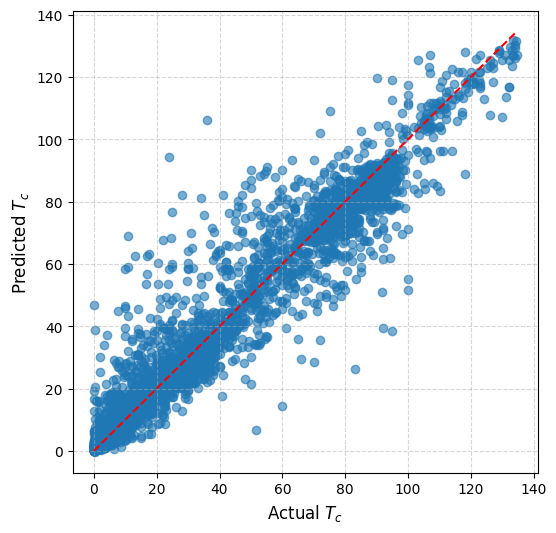

In [12]:
# Predicted vs Actual Plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--')
plt.xlabel("Actual $T_c$", fontsize=12)
plt.ylabel("Predicted $T_c$", fontsize=12)
# plt.title("Predicted vs Actual $T_c$ (Stacking Model)", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.5)
#save high resolution image
plt.savefig("predicted_vs_actual_Tc.png", dpi =1000, bbox_inches = 'tight')
plt.show()

In [ ]:
# stack_ridge = StackingRegressor(
#     estimators = base_model_83,
#     final_estimator =  RidgeCV(),
#     cv = KFold(n_splits=10, shuffle = True, random_state = 42),
#     passthrough=True,
#     n_jobs=-1
#     )
# #train
# stack_ridge.fit(X_train, y_train)
# #prediction
# y_pred_ridge = stack_ridge.predict(X_test)
# r2 = r2_score(y_test, y_pred_ridge)
# model_evaluation("meta model ridgeCV",y_test,y_pred_ridge)

meta model ridgeCV

Mean absolute error: 4.917314735434315
Mean squared error: 72.67469210900552
RMSE:  8.524945284810075
r2_score: 0.9368639334801007
